Can we find distinct behavioral types of users who spread misinformation?

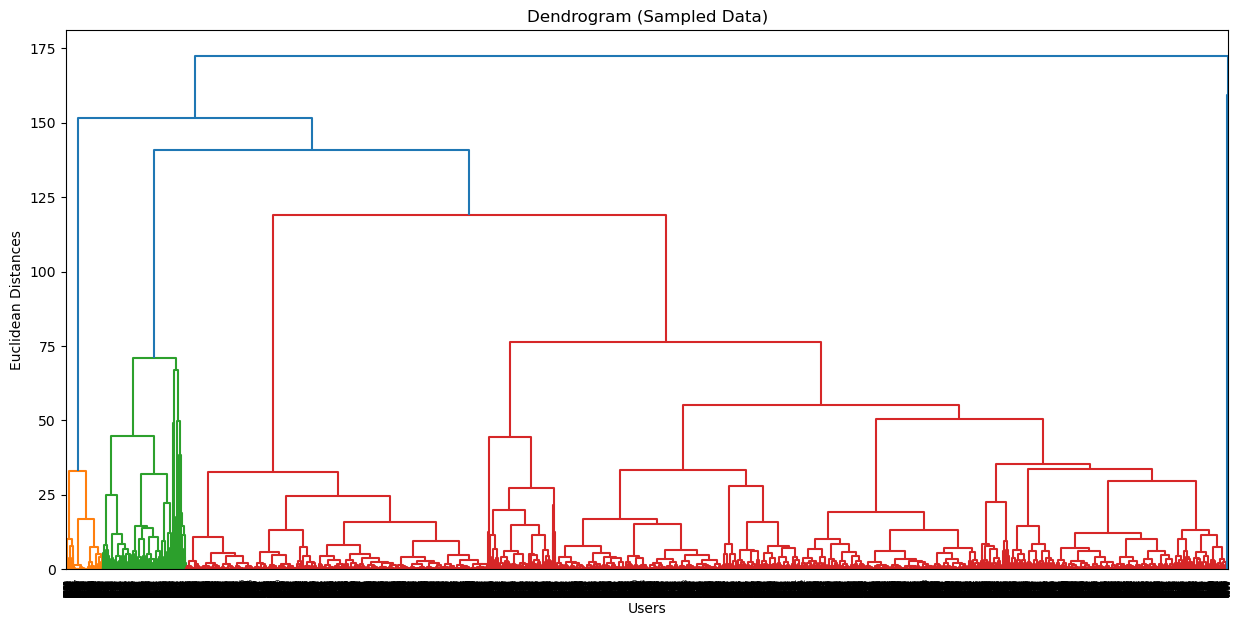

In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Features_For_Traditional_ML_Techniques.csv")

features = [
    'followers_count', 'friends_count', 'favourites_count', 
    'statuses_count', 'BotScore', 'cred', 
    'normalize_influence', 'replies', 'retweets'
]

# Drop missing values
df_clean = df.dropna(subset=features + ['BinaryNumTarget'])


# Stratified Sampling (Subset the Data) Since this algorithm crashes with large dataset
#you can try it with full dataset if it works for you

# We sample 10,000 points while maintaining the ratio of True/Fake news.
# Instead of taking a truly random sample of 10,000 rows (which might end up with 9,000 True and only 1,000 Fake), 
# this code ensures you take equal amounts of True and Fake news (5,000 each). This ensures the model learns equally 
#from both types of news.

sample_size = 10000
df_sample = df_clean.groupby('BinaryNumTarget', group_keys=False).apply(
    lambda x: x.sample(min(len(x), sample_size // 2))
)

# lambda x takes each group (the True group and the Fake group) one by one.
# len(x) checks how many rows are in that specific group.
# sample_size // 2 calculates half of total desired sample size ($10,000 // 2 = 5,000$)
# min(len(x), ...) - is a safety check. If a specific group (e.g., Fake News) has fewer than 5,000 rows, 
# it takes all available rows instead of crashing.

X_sample = df_sample[features]

# Scale the sampled features
scaler = StandardScaler()
X_sample_scaled = scaler.fit_transform(X_sample)


# Create a Dendrogram (To choose K)

plt.figure(figsize=(15, 7))
plt.title("Dendrogram (Sampled Data)")
# Using 'ward' linkage minimizes variance within clusters
dendrogram = sch.dendrogram(sch.linkage(X_sample_scaled, method='ward'))
#This line performs the actual hierarchical clustering algorithm. 
#It calculates all the pairwise distances and merges points together step-by-step to build the complete tree structure.

plt.xlabel("Users")
plt.ylabel("Euclidean Distances")
plt.savefig("tweet_dendrogram.png")
plt.show()                

Looking at your dendrogram, k=3 seems to be a strong candidate because the vertical distances between the merges are quite large in that area, indicating that the clusters formed are significantly different from each other.

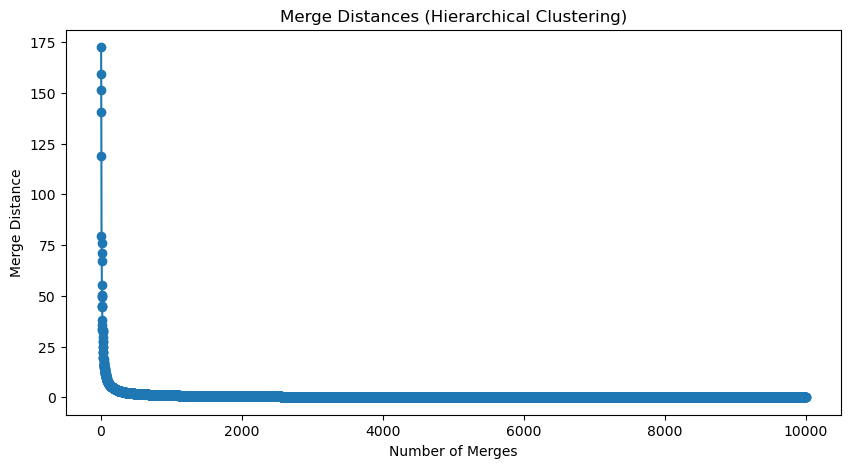

In [8]:
from scipy.cluster.hierarchy import linkage
import matplotlib.pyplot as plt

# Perform linkage
Z = linkage(X_sample_scaled, method='ward')

# Extract distances (the third column of Z)
distances = Z[:, 2]

# Reverse the distances to show them in descending order (highest to lowest)
distances = sorted(distances, reverse=True)

# Plot the distances
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(distances) + 1), distances, marker='o')
plt.title('Merge Distances (Hierarchical Clustering)')
plt.xlabel('Number of Merges')
plt.ylabel('Merge Distance')
plt.savefig("mergedistance.png")
plt.show()

This plot shows the distance at which clusters are merged, starting from the very last merge on the left to the first merge on the right.
You look at the first 2 or 3 dots on the left and see that they have high distances, and then the distance drops significantly. 
That sharp drop signifies that the merges to the right of it are combining clusters that are much more similar, which is why we stop early.
Look for the steep drop: On the far left, the merge distances are very high (>150). This means the algorithm is merging very distinct groups.
Find the elbow: The steep drop levels off sharply around k=3 or k=4 merges.

In [9]:
# Run Agglomerative Clustering

# Based on the dendrogram, choose the number of clusters (e.g., 3 or 4)
optimal_k = 4
hc = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
#The above line performs the partitioning step.instead of just building the tree, 
#this sklearn function tells the algorithm to "cut" the tree structure created in the previous step 
#specifically at the level that results in n_clusters=4.

df_sample['Cluster'] = hc.fit_predict(X_sample_scaled)


# Analyze Results on Sampled Data

cluster_analysis = df_sample.groupby('Cluster').agg({
    'BinaryNumTarget': ['mean', 'count'],
    'followers_count': 'mean',
    'BotScore': 'mean'
})
cluster_analysis['FakeNewsPropensity'] = 1 - cluster_analysis[('BinaryNumTarget', 'mean')]
print(cluster_analysis)

        BinaryNumTarget       followers_count  BotScore FakeNewsPropensity
                   mean count            mean      mean                   
Cluster                                                                   
0              0.501034  9674    1.099082e+04  0.028418           0.498966
1              0.750000     8    4.171307e+06  0.030000           0.250000
2              1.000000     1    1.306019e+08  0.030000           0.000000
3              0.460568   317    6.955836e+01  0.976215           0.539432


Cluster 0 and 3 have high fake propensity compared to the rest (~50%).But cluster 0 has high count (size) compared to cluster 3
Indicates typical users spreading a mix of content.

By looking at followers_count and BotScore, we can define what these clusters do.
cluster 3 has high botscore. Misinformation rate is 54% (More Fake than True)

cluster 0 depicts typical accounts that make up the bulk of the data. They do not have a strong agenda but frequently share misinformation, likely because they do not verify information before posting.

cluster 1 has low bot score but high number of followes and low fake news score, maybe celebrities or other verified accounts?

Both algorithms conclude that misinformation is driven by a combination of automated bot accounts (high BotScore) and highly influential outliers (high follower count), while the general population has a near-random probability of sharing fake news.